In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

print(os.listdir('/content/drive/MyDrive/D2C_Churn_Capstone/datasets'))

['churn_labels.csv', 'customers.csv', 'DATA_DICTIONARY.md', 'intervention_history.csv', 'orders.csv', 'rfm_modeling_snapshot.csv', 'support_tickets.csv', 'web_events_snapshot.csv']


In [4]:
base_path = "/content/drive/MyDrive/D2C_Churn_Capstone/datasets"

customers = pd.read_csv(f"{base_path}/customers.csv")
orders = pd.read_csv(f"{base_path}/orders.csv")
support = pd.read_csv(f"{base_path}/support_tickets.csv")
web = pd.read_csv(f"{base_path}/web_events_snapshot.csv")
churn = pd.read_csv(f"{base_path}/churn_labels.csv")
intervention = pd.read_csv(f"{base_path}/intervention_history.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support:", support.shape)
print("Web:", web.shape)
print("Churn:", churn.shape)
print("Intervention:", intervention.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support: (1921, 8)
Web: (2400, 10)
Churn: (2400, 4)
Intervention: (2400, 5)


In [6]:
print("CUSTOMERS")
print(customers.columns)

CUSTOMERS
Index(['customer_id', 'signup_date', 'city_tier', 'age_group',
       'acquisition_channel', 'loyalty_tier', 'preferred_category',
       'skin_type', 'marketing_consent'],
      dtype='object')


In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB


In [8]:
customers.isnull().sum()

,0
customer_id,0
signup_date,0
city_tier,0
age_group,0
acquisition_channel,0
loyalty_tier,1386
preferred_category,0
skin_type,401
marketing_consent,0


In [9]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [10]:
customers.describe(include='all')

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
count,2400,2400,2400,2400,2400,1014,2400,1999,2400
unique,2400,609,3,4,6,3,6,5,2
top,CUST02384,2024-10-12,Tier 1,25-34,Instagram,Silver,Skin Care,Oily,Yes
freq,1,11,1005,1045,517,590,731,420,1760


## Customer Dataset Findings

- Dataset contains 2,400 customers and 9 columns.
- Customer IDs are unique (2,400 unique IDs).
- No duplicate customer records were found.
- Loyalty tier contains 1,386 missing values (~57.8%).
- Missing loyalty tier likely indicates customers not enrolled in the loyalty program.
- Skin type contains 401 missing values (~16.7%).
- Most customers belong to Tier 1 cities.
- The 25–34 age group is currently the largest customer segment in the customer dataset.

In [11]:
customers['customer_id'].nunique()

2400

In [12]:
customers['customer_id'].duplicated().sum()

np.int64(0)

# Orders Dataset Audit

In [13]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating'],
      dtype='object')

In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 non-null  object 
 3   category       10009 non-null  object 
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 782.1+ KB


In [15]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
category,0
quantity,0
gross_amount,0
discount_pct,0
delivery_days,0
returned,0
rating,80


In [16]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


## Orders Dataset Findings

- Dataset contains 10,009 order records and 10 columns.
- All order IDs are unique.
- No duplicate order IDs were identified.
- Only the `rating` field contains missing values (80 records).
- Average order value is approximately ₹744.
- Most orders contain 1–2 items.
- Average discount offered is approximately 27%.
- Average delivery time is approximately 4.5 days.
- Around 6.7% of orders were returned.
- Order values show potential high-value outliers that require further investigation.

In [17]:
orders['order_id'].nunique()

10009

In [18]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [19]:
orders.describe()

,quantity,gross_amount,discount_pct,delivery_days,returned,rating
count,10009.000000,10009.000000,10009.000000,10009.000000,10009.000000,9929.000000
mean,1.507943,743.898504,0.274121,4.454591,0.067439,3.885487
std,0.764261,600.564068,0.125525,1.769649,0.250794,1.159465
min,1.000000,149.000000,0.000000,1.000000,0.000000,1.000000
25%,1.000000,432.850000,0.190000,3.000000,0.000000,3.000000
50%,1.000000,597.060000,0.270000,4.000000,0.000000,4.000000
75%,2.000000,907.430000,0.360000,6.000000,0.000000,5.000000
max,4.000000,24789.380000,0.700000,11.000000,1.000000,5.000000


In [20]:
orders['gross_amount'].sort_values(ascending=False).head(10)

,gross_amount
7810,24789.38
874,22719.45
8836,15957.48
8328,12312.12
5450,10643.82
5721,8777.20
6625,8022.50
9523,3746.76
626,3376.32
1377,3341.27


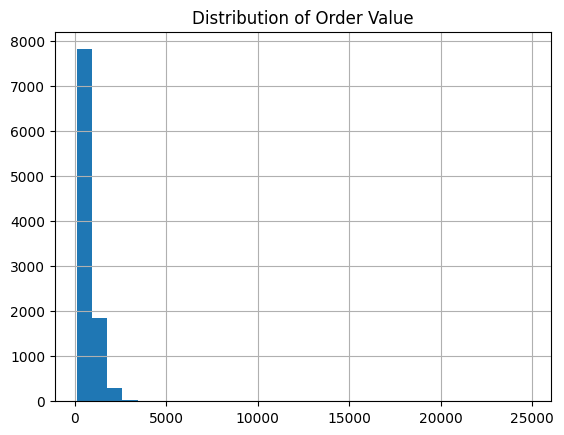

In [21]:
orders['gross_amount'].hist(bins=30)
plt.title("Distribution of Order Value")
plt.show()

In [22]:
orders['category'].value_counts()

,count
category,
Skin Care,2700
Hair Care,2191
Makeup,1507
Baby Care,1438
Wellness,1096
Fragrance,1077


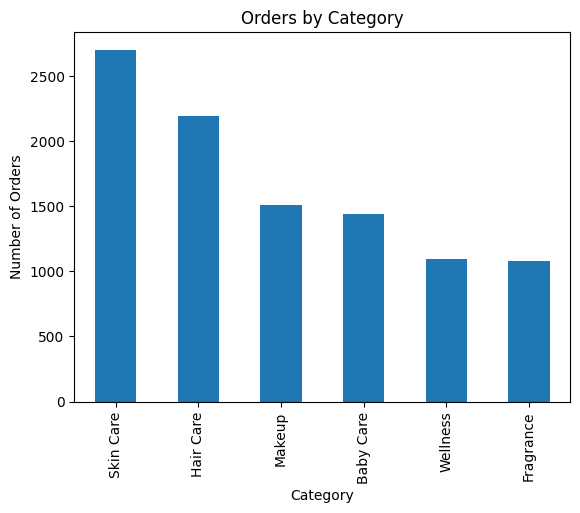

In [23]:
orders['category'].value_counts().plot(kind='bar')

plt.title("Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.show()

## Category Analysis Findings
- Skin Care is the most frequently purchased category with 2,700 orders.
- Hair Care is the second most popular category with 2,191 orders.
- Makeup and Baby Care show moderate order volumes with 1,507 and 1,438 orders respectively.
- Wellness and Fragrance are the least purchased categories, each contributing approximately 1,100 orders.
- Customer demand appears strongest in core beauty and personal care products, particularly Skin Care and Hair Care.
- Product category preferences may influence customer retention and churn behavior.

In [24]:
orders['returned'].value_counts()

,count
returned,
0,9334
1,675


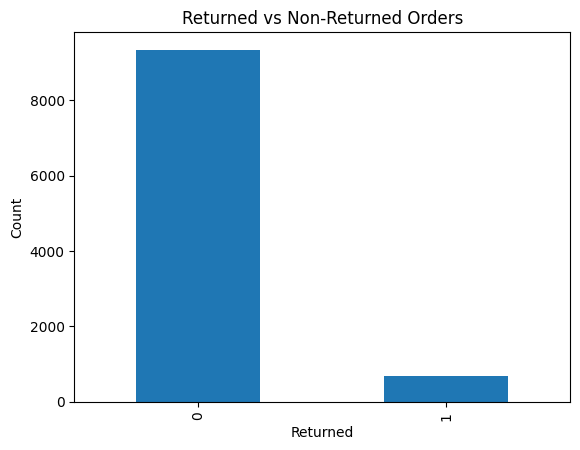

In [25]:
orders['returned'].value_counts().plot(kind='bar')

plt.title("Returned vs Non-Returned Orders")
plt.xlabel("Returned")
plt.ylabel("Count")

plt.show()

## Return Analysis Findings

- Out of 10,009 orders, 9,334 were successfully retained and 675 were returned.
- Approximately 6.7% of all orders were returned.
- The majority of customers appear satisfied with their purchases, as the return rate is relatively low.
- Returned orders may indicate customer dissatisfaction and could be an important predictor of churn.
- Return behavior should be considered during customer segmentation and churn modeling.

In [26]:
orders['rating'].describe()

,rating
count,9929.000000
mean,3.885487
std,1.159465
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [27]:
orders['rating'].value_counts().sort_index()

,count
rating,
1.0,539
2.0,803
3.0,1664
4.0,3173
5.0,3750


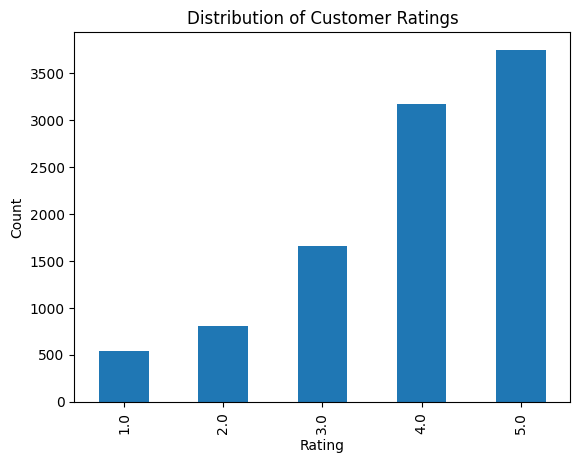

In [28]:
orders['rating'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

## Rating Analysis Findings

- The average customer rating is approximately 3.89 out of 5.
- The median rating is 4, indicating generally positive customer feedback.
- Rating 5 is the most common rating with 3,750 reviews.
- Rating 4 is the second most common rating with 3,173 reviews.
- Approximately 70% of ratings are either 4 or 5 stars.
- Low ratings (1 and 2 stars) account for a relatively small portion of reviews.
- Overall customer satisfaction appears positive based on the rating distribution.
- Customer ratings may serve as an important predictor of churn behavior.

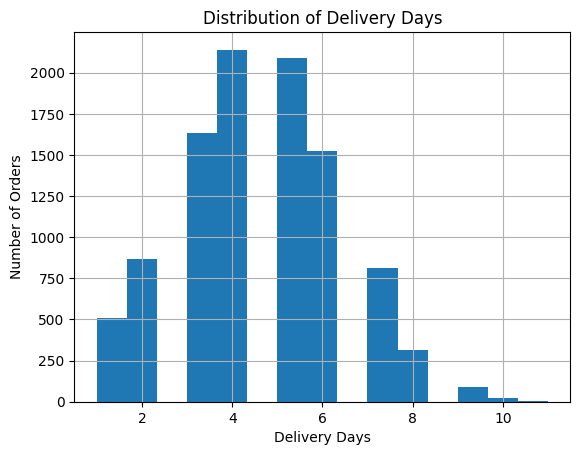

In [29]:
orders['delivery_days'].hist(bins=15)

plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.show()

## Delivery Analysis Findings

- Most orders are delivered within 3–6 days.
- The average delivery time is approximately 4.45 days.
- Delivery performance appears relatively consistent across orders.
- Very few orders take longer than 8 days to arrive.
- The distribution suggests efficient logistics and fulfillment operations.
- Longer delivery times may contribute to customer dissatisfaction and should be examined further during churn analysis.
- Delivery speed could be an important feature for churn prediction models.

# Support Tickets Dataset Audit

In [30]:
print("SUPPORT TICKETS")
print(support.columns)

SUPPORT TICKETS
Index(['ticket_id', 'customer_id', 'ticket_date', 'issue_type',
       'support_channel', 'resolution_hours', 'sentiment_score', 'reopened'],
      dtype='object')


In [31]:
support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   object 
 1   customer_id       1921 non-null   object 
 2   ticket_date       1921 non-null   object 
 3   issue_type        1921 non-null   object 
 4   support_channel   1921 non-null   object 
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 120.2+ KB


In [32]:
support.isnull().sum()

,0
ticket_id,0
customer_id,0
ticket_date,0
issue_type,0
support_channel,0
resolution_hours,0
sentiment_score,0
reopened,0


In [33]:
support.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


In [34]:
support.describe(include='all')

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
count,1921,1921,1921,1921,1921,1921.000000,1921.000000,1921.000000
unique,1921,1247,526,7,3,NaN,NaN,NaN
top,TKT001921,CUST00487,2025-09-30,late_delivery,email,NaN,NaN,NaN
freq,1,6,51,377,671,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,24.789276,-0.440770,0.176991
std,NaN,NaN,NaN,NaN,NaN,14.270666,0.473244,0.381761
min,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,14.400000,-0.890000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,24.200000,-0.490000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,34.600000,-0.110000,0.000000


## Support Tickets Dataset Findings

- Dataset contains 1,921 support tickets and 8 columns.
- No missing values were found in any column.
- Ticket IDs are unique, indicating no duplicate ticket records.
- Tickets were raised by 1,247 unique customers.
- Support interactions are captured through 3 channels: Email, Chat, and Call.
- There are 7 different issue categories recorded.
- Late delivery is the most common support issue, with 377 tickets.
- Email is the most frequently used support channel, with 671 interactions.
- The dataset provides valuable information on customer service experience and satisfaction.
- Support behavior may be useful for identifying customers at risk of churn.

In [35]:
support['resolution_hours'].describe()

,resolution_hours
count,1921.000000
mean,24.789276
std,14.270666
min,1.000000
25%,14.400000
50%,24.200000
75%,34.600000
max,74.600000


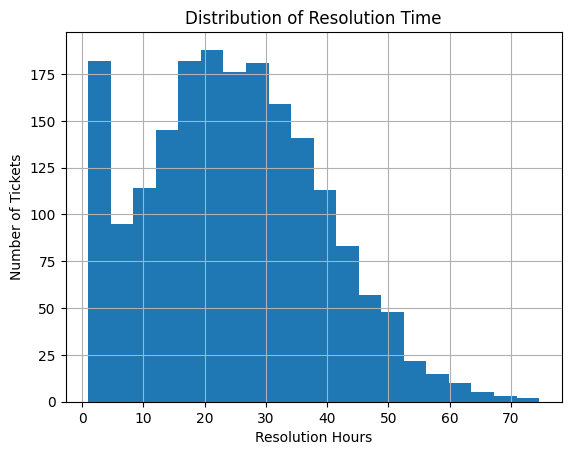

In [36]:
support['resolution_hours'].hist(bins=20)

plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Hours")
plt.ylabel("Number of Tickets")

plt.show()

## Resolution Time Findings

- The average ticket resolution time is approximately 24.8 hours.
- The median resolution time is 24.2 hours, indicating that most tickets are resolved within one day.
- 50% of tickets are resolved between 14.4 and 34.6 hours.
- Most support requests are resolved within 1–2 days.
- A small number of tickets require significantly longer resolution times, reaching up to 74.6 hours.
- The distribution suggests generally efficient customer support operations.
- Longer resolution times may negatively impact customer satisfaction and increase churn risk.
- Resolution time should be considered as a potential churn predictor.

In [37]:
support['sentiment_score'].describe()

,sentiment_score
count,1921.000000
mean,-0.440770
std,0.473244
min,-1.000000
25%,-0.890000
50%,-0.490000
75%,-0.110000
max,1.000000


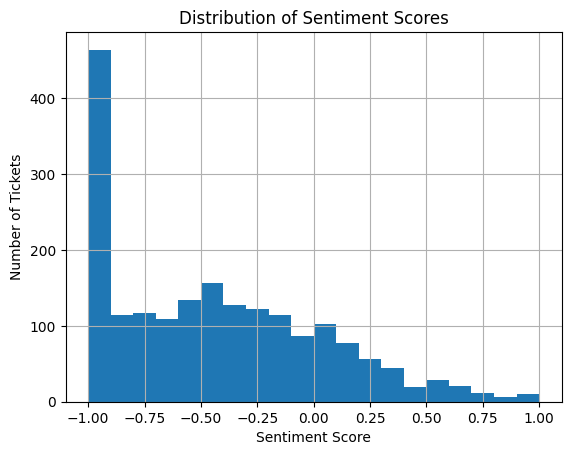

In [38]:
support['sentiment_score'].hist(bins=20)

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Tickets")

plt.show()

In [39]:
support['reopened'].value_counts()

,count
reopened,
0,1581
1,340


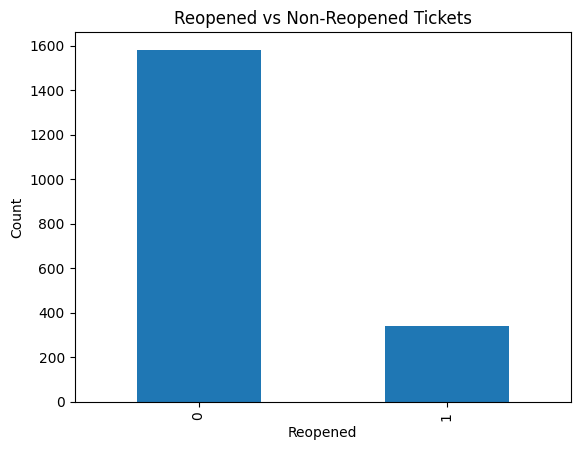

In [40]:
support['reopened'].value_counts().plot(kind='bar')

plt.title("Reopened vs Non-Reopened Tickets")
plt.xlabel("Reopened")
plt.ylabel("Count")

plt.show()

## Sentiment Analysis Findings

- The average sentiment score is approximately -0.44.
- Sentiment scores range from -1 (highly negative) to +1 (highly positive).
- The distribution is skewed toward negative sentiment values.
- Many support interactions appear to involve dissatisfied customers.
- Positive sentiment scores are comparatively less common.
- Customer sentiment may provide valuable insights into customer satisfaction levels.
- Negative sentiment could serve as a strong predictor of customer churn.

## Reopened Ticket Findings

- Out of 1,921 support tickets, 340 were reopened and 1,581 were resolved without reopening.
- Approximately 17.7% of tickets required additional follow-up after initial resolution.
- The majority of support issues appear to be resolved successfully on the first attempt.
- Reopened tickets may indicate unresolved customer concerns or service quality issues.
- Customers with repeated support interactions may have a higher likelihood of churning.
- Ticket reopening behavior should be considered during churn modeling and customer segmentation.

# Web Events Dataset Audit

In [41]:
print("WEB EVENTS")
print(web.columns)

WEB EVENTS
Index(['customer_id', 'snapshot_date', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago'],
      dtype='object')


In [42]:
web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   snapshot_date        2400 non-null   object
 2   sessions_30d         2400 non-null   int64 
 3   product_views_30d    2400 non-null   int64 
 4   cart_adds_30d        2400 non-null   int64 
 5   wishlist_adds_30d    2400 non-null   int64 
 6   abandoned_carts_30d  2400 non-null   int64 
 7   email_opens_30d      2400 non-null   int64 
 8   campaign_clicks_30d  2400 non-null   int64 
 9   last_visit_days_ago  2400 non-null   int64 
dtypes: int64(8), object(2)
memory usage: 187.6+ KB


In [43]:
web.isnull().sum()

,0
customer_id,0
snapshot_date,0
sessions_30d,0
product_views_30d,0
cart_adds_30d,0
wishlist_adds_30d,0
abandoned_carts_30d,0
email_opens_30d,0
campaign_clicks_30d,0
last_visit_days_ago,0


In [44]:
web.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [45]:
web.describe(include='all')

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
count,2400,2400,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
unique,2400,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST02384,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,5.460000,23.021667,1.560833,0.839167,0.672917,2.645833,0.649583,17.652500
std,NaN,NaN,4.400167,19.818043,1.644919,0.996015,0.867225,2.763346,0.951579,15.905806
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,NaN,NaN,5.000000,18.000000,1.000000,1.000000,0.000000,2.000000,0.000000,14.000000
75%,NaN,NaN,8.000000,34.000000,2.000000,1.000000,1.000000,5.000000,1.000000,27.000000


## Web Events Dataset Findings

- Dataset contains 2,400 customer web activity records and 10 columns.
- No missing values were found in any column.
- Customer IDs are unique, indicating one activity snapshot per customer.
- All records were captured on the same snapshot date: 2025-09-30.
- Customers average approximately 5.5 website sessions in the last 30 days.
- Customers view approximately 23 products on average during the last 30 days.
- User engagement varies considerably across customers, as indicated by the spread of session and product view counts.
- Web behavior metrics provide valuable indicators of customer engagement and purchase intent.
- Features such as sessions, product views, cart additions, and abandoned carts may be important predictors of customer churn.

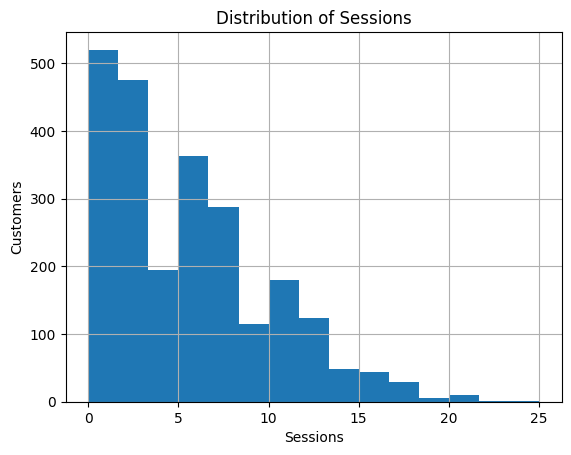

In [46]:
web['sessions_30d'].hist(bins=15)

plt.title("Distribution of Sessions")
plt.xlabel("Sessions")
plt.ylabel("Customers")

plt.show()

## Sessions Analysis Findings

- Customers average approximately 5.5 website sessions in the last 30 days.
- Most customers have between 1 and 8 sessions.
- The distribution is right-skewed, with fewer customers having very high session counts.
- A small number of highly engaged customers have more than 15 sessions.
- Customer engagement levels vary significantly across the customer base.
- Higher session frequency may indicate stronger customer interest and loyalty.
- Low session counts may signal reduced engagement and potential churn risk.
- Website session activity is likely to be an important predictor in churn modeling.

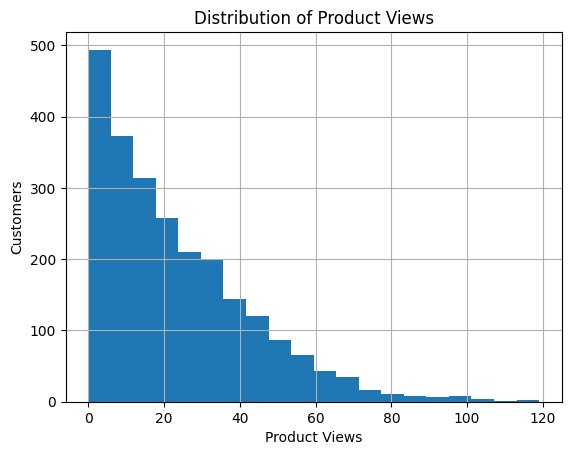

In [47]:
web['product_views_30d'].hist(bins=20)

plt.title("Distribution of Product Views")
plt.xlabel("Product Views")
plt.ylabel("Customers")

plt.show()

## Product Views Analysis Findings

- Customers view approximately 23 products on average in a 30-day period.
- Most customers view fewer than 35 products.
- The distribution is positively skewed, with a small number of customers viewing a very large number of products.
- Some highly engaged customers view more than 80 products within 30 days.
- Product browsing behavior varies considerably across customers.
- Higher product view counts may indicate strong purchase intent and customer interest.
- Customers with very low product view activity may be less engaged and potentially at higher risk of churn.
- Product view activity is likely to be a valuable feature for customer segmentation and churn prediction.

In [48]:
web['cart_adds_30d'].describe()

,cart_adds_30d
count,2400.000000
mean,1.560833
std,1.644919
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,12.000000


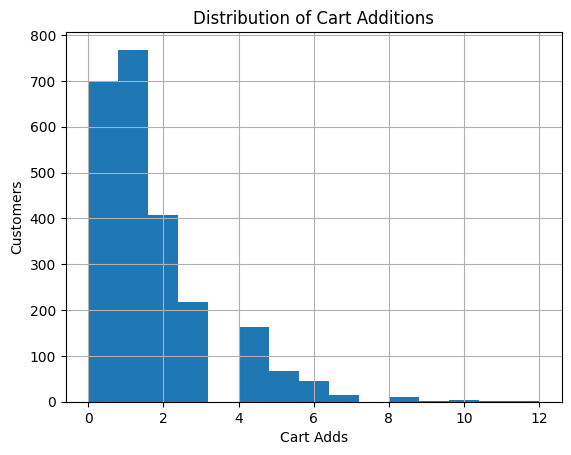

In [49]:
web['cart_adds_30d'].hist(bins=15)

plt.title("Distribution of Cart Additions")
plt.xlabel("Cart Adds")
plt.ylabel("Customers")

plt.show()

## Cart Additions Analysis Findings

- Customers add approximately 1.6 items to their cart on average within a 30-day period.
- The median number of cart additions is 1, indicating relatively modest purchase activity for most customers.
- Approximately 25% of customers do not add any products to their cart.
- The distribution is positively skewed, with most customers making between 0 and 3 cart additions.
- A small group of highly engaged customers add significantly more products, reaching up to 12 cart additions.
- Cart addition behavior varies across customers and may reflect differences in purchase intent.
- Higher cart addition counts generally indicate stronger buying interest and customer engagement.
- Customers with no cart activity may be less engaged and potentially at higher risk of churn.
- Cart additions are likely to be an important feature for customer segmentation and churn prediction.

In [50]:
web['wishlist_adds_30d'].describe()

,wishlist_adds_30d
count,2400.000000
mean,0.839167
std,0.996015
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,6.000000


## Wishlist Additions Analysis Findings

- Customers add approximately 0.84 products to their wishlist on average within a 30-day period.
- The median wishlist addition count is 1, indicating that at least half of customers add one or fewer products to their wishlist.
- Approximately 25% of customers do not add any products to their wishlist.
- Most customers add between 0 and 1 products, suggesting relatively low wishlist activity overall.
- A small number of highly engaged customers add multiple products, with a maximum of 6 wishlist additions.
- Wishlist activity appears lower than cart addition activity, indicating stronger purchase intent among customers who move products directly to their cart.
- Customers with higher wishlist counts may represent interested buyers who have not yet completed purchases.
- Wishlist behavior can provide valuable insights into customer preferences and future purchasing intentions.
- Wishlist additions may serve as a useful feature for customer segmentation and churn prediction models.

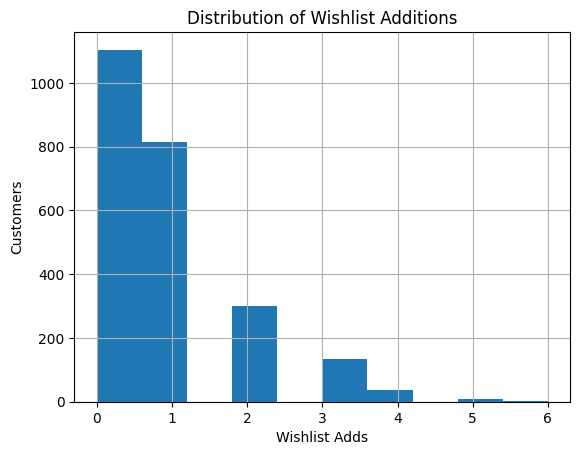

In [51]:
web['wishlist_adds_30d'].hist(bins=10)

plt.title("Distribution of Wishlist Additions")
plt.xlabel("Wishlist Adds")
plt.ylabel("Customers")

plt.show()

In [52]:
web['abandoned_carts_30d'].describe()

,abandoned_carts_30d
count,2400.000000
mean,0.672917
std,0.867225
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,7.000000


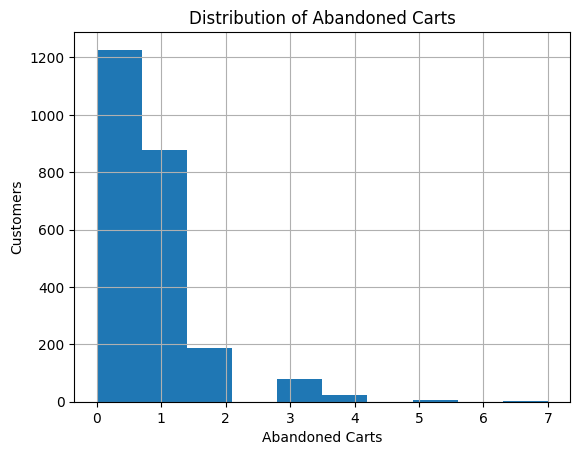

In [53]:
web['abandoned_carts_30d'].hist(bins=10)

plt.title("Distribution of Abandoned Carts")
plt.xlabel("Abandoned Carts")
plt.ylabel("Customers")

plt.show()

## Abandoned Cart Analysis Findings

- Customers abandon approximately 0.67 carts on average within a 30-day period.
- The median abandoned cart count is 0, indicating that at least half of customers do not abandon any carts.
- Approximately 25% of customers have no abandoned carts, while 75% have one or fewer abandoned carts.
- Most customers exhibit low cart abandonment behavior.
- A small group of customers shows higher abandonment activity, with a maximum of 7 abandoned carts.
- The distribution is positively skewed, with the majority of observations concentrated at lower values.
- Frequent cart abandonment may indicate purchase hesitation, pricing concerns, or checkout friction.
- Customers with higher abandoned cart counts may be at greater risk of churn if they repeatedly fail to complete purchases.
- Abandoned cart behavior can serve as an important indicator of purchase intent and customer engagement.
- This feature is likely to be highly valuable for customer segmentation and churn prediction models.

In [54]:
web['email_opens_30d'].describe()

,email_opens_30d
count,2400.000000
mean,2.645833
std,2.763346
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,13.000000


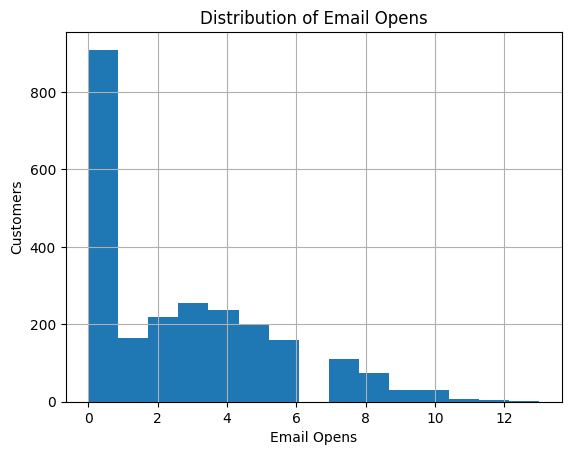

In [55]:
web['email_opens_30d'].hist(bins=15)

plt.title("Distribution of Email Opens")
plt.xlabel("Email Opens")
plt.ylabel("Customers")

plt.show()

## Email Opens Analysis Findings

- Customers open approximately 2.65 marketing emails on average within a 30-day period.
- The median email open count is 2, indicating that half of customers open two or fewer emails.
- Approximately 25% of customers do not open any marketing emails.
- The top 25% of customers open more than 5 emails, reflecting a highly engaged customer segment.
- Email engagement varies considerably across customers, with counts ranging from 0 to 13 opens.
- The distribution is positively skewed, with many customers showing low engagement and a smaller group exhibiting high engagement.
- Customers with higher email open activity are likely more responsive to marketing campaigns and promotions.
- Low or zero email engagement may indicate reduced customer interest or potential churn risk.
- Email open behavior provides valuable insight into customer engagement and communication effectiveness.
- Email engagement metrics can be important predictors for customer retention, segmentation, and churn prediction models.

In [56]:
web['campaign_clicks_30d'].describe()

,campaign_clicks_30d
count,2400.000000
mean,0.649583
std,0.951579
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,6.000000


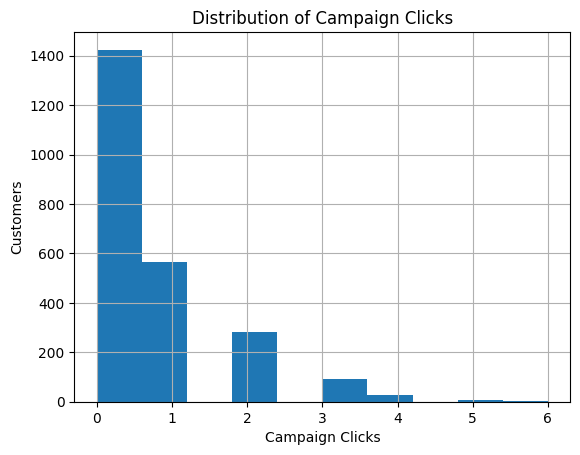

In [57]:
web['campaign_clicks_30d'].hist(bins=10)

plt.title("Distribution of Campaign Clicks")
plt.xlabel("Campaign Clicks")
plt.ylabel("Customers")

plt.show()

## Campaign Clicks Analysis Findings

- Customers click on approximately 0.65 marketing campaign links on average within a 30-day period.
- The median campaign click count is 0, indicating that at least half of customers do not click on marketing campaign links.
- Approximately 25% of customers record no campaign clicks, while 75% have one or fewer clicks.
- Campaign click activity is generally low across the customer base.
- A small group of highly engaged customers clicks multiple campaign links, with a maximum of 6 clicks.
- The distribution is positively skewed, with most customers concentrated at lower click counts.
- Campaign clicks represent a stronger form of engagement than email opens because they indicate active customer interaction.
- Customers who frequently click campaign links are likely more interested in promotions, products, and marketing content.
- Low or zero campaign click activity may signal reduced engagement and potential churn risk.
- Campaign click behavior can be a valuable feature for customer segmentation, retention analysis, and churn prediction models.

In [58]:
web['last_visit_days_ago'].describe()

,last_visit_days_ago
count,2400.000000
mean,17.652500
std,15.905806
min,0.000000
25%,4.000000
50%,14.000000
75%,27.000000
max,60.000000


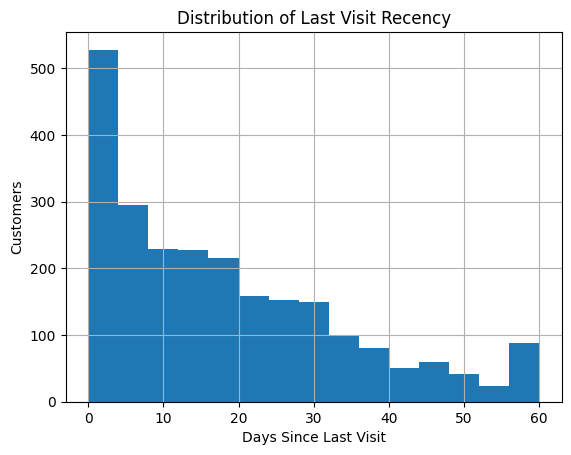

In [59]:
web['last_visit_days_ago'].hist(bins=15)

plt.title("Distribution of Last Visit Recency")
plt.xlabel("Days Since Last Visit")
plt.ylabel("Customers")

plt.show()

## Last Visit Recency Analysis Findings

- Customers last visited the website approximately 17.7 days ago on average.
- The median recency is 14 days, indicating that half of customers visited within the last two weeks.
- Approximately 25% of customers visited within the last 4 days.
- Approximately 75% of customers visited within the last 27 days.
- Recency values range from 0 to 60 days, showing substantial variation in customer activity levels.
- Customers with very recent visits are likely more engaged and actively interacting with the platform.
- Longer periods since the last visit may indicate declining customer engagement.
- The distribution is expected to highlight both active and inactive customer segments.
- Website visit recency is one of the strongest behavioral indicators of customer engagement and loyalty.
- Customers who have not visited for extended periods may be at a higher risk of churn.
- Recency metrics should be considered a critical feature for customer segmentation and churn prediction models.

# Web Events Dataset Summary Findings

- The dataset contains 2,400 customer activity records with no missing values.
- Customer engagement varies significantly across website sessions, product views, cart additions, wishlist additions, email interactions, and campaign clicks.
- Most behavioral metrics exhibit positively skewed distributions, where a small number of highly engaged customers account for a large portion of activity.
- Product views and website sessions indicate varying levels of customer interest and browsing behavior.
- Cart additions and wishlist activity provide insight into purchase intent and product consideration.
- Abandoned cart behavior may reveal friction points in the customer purchase journey.
- Email opens and campaign clicks serve as important indicators of marketing engagement.
- Recency metrics capture how recently customers interacted with the platform and can help identify inactive users.
- Together, these behavioral variables provide valuable signals for customer segmentation, personalization, retention analysis, and churn prediction.
- Features such as recency, product views, cart additions, abandoned carts, email engagement, and campaign clicks are likely to be among the most informative predictors of customer churn.

# Part 1 EDA Summary

## Key Findings

- Orders dataset shows strong customer satisfaction with low return rates and generally positive ratings.
- Skin Care and Hair Care are the most popular product categories.
- Delivery performance is consistent, with most orders delivered within 3–6 days.
- Support tickets indicate that late delivery is the most common customer issue.
- Customer sentiment is generally negative within support interactions, suggesting support cases often involve dissatisfied customers.
- Most support tickets are resolved successfully without reopening.
- Web activity metrics reveal significant variation in customer engagement.
- Customers with recent visits, higher session counts, product views, cart additions, and marketing engagement appear more active.
- Features such as recency, abandoned carts, campaign clicks, support sentiment, return behavior, and ratings may be valuable predictors for customer churn modeling.

## Next Steps

- Merge datasets at the customer level.
- Perform feature engineering.
- Analyze relationships with churn labels.
- Prepare data for predictive modeling.

# Data Quality Report
## Missing Values

### Customers Dataset
- loyalty_tier: 1,386 missing values (~57.8%)
- skin_type: 401 missing values (~16.7%)

Observation:
- Missing loyalty_tier likely indicates customers not enrolled in the loyalty program.
- Missing skin_type likely indicates customers who did not provide this information.

### Orders Dataset
- rating: 80 missing values

Observation:
- Missing ratings likely represent customers who did not submit reviews.

### Support Tickets Dataset
- No missing values detected.

### Web Events Dataset
- No missing values detected.

## Duplicate Records

### Customers Dataset
- Customer IDs are unique.
- Duplicate customer records: 0

### Orders Dataset
- Order IDs are unique.
- Duplicate order records: 0

### Support Tickets Dataset
- Ticket IDs appear unique.

### Web Events Dataset
- One activity snapshot per customer.

## Outlier Assessment

### Orders Dataset
- Maximum order value: ₹24,789.38
- Average order value: ₹743.90

Observation:
- A small number of high-value orders appear significantly larger than average.
- These may represent premium customers rather than data errors.

### Support Dataset
- Resolution time reaches approximately 74.6 hours.
- These records should be reviewed but may represent complex support cases.

## Potential Data Leakage Risks

The following columns require special attention during predictive modeling:

- churn labels
- future customer activity
- future orders
- post-snapshot interactions

Recommendation:
Only information available on or before the snapshot date should be used when building churn prediction models.

## Overall Assessment

Data quality is generally good.

Key observations:
- Missing values are limited and mostly explainable through business context.
- No significant duplicate record issues were identified.
- A small number of high-value transactions exist but appear realistic.
- Support and web activity datasets are complete and suitable for analysis.
- Care should be taken to avoid data leakage when building predictive models.

# Churn-Risk Hypotheses

## Hypothesis 1: Customers with lower website activity are more likely to churn

Evidence:
- Customers with fewer sessions, product views, and cart additions show lower engagement levels.
- Web activity metrics displayed significant variation across customers.

Business Impact:
- Low engagement customers should be prioritized for retention campaigns and re-engagement strategies.

## Hypothesis 2: Customers with longer periods since their last visit are more likely to churn

Evidence:
- The average last visit recency was approximately 17.7 days.
- Customers with higher recency values appear less engaged with the platform.

Business Impact:
- Recency should be monitored closely as an early warning signal for churn.

## Hypothesis 3: Customers who frequently abandon carts are more likely to churn

Evidence:
- Customers exhibit varying levels of cart abandonment behavior.
- Repeated abandoned carts may indicate hesitation or dissatisfaction during the purchase journey.

Business Impact:
- Abandoned cart reminders and targeted offers may improve retention.

## Hypothesis 4: Customers with negative support interactions are more likely to churn

Evidence:
- The average support sentiment score was negative.
- Reopened tickets and longer resolution times may indicate unresolved customer concerns.

Business Impact:
- Improving customer support quality may reduce churn risk.

## Hypothesis 5: Customers with low marketing engagement are more likely to churn

Evidence:
- Many customers recorded few email opens and campaign clicks.
- Campaign engagement metrics showed substantial variation across the customer base.

Business Impact:
- Marketing engagement can be used to identify at-risk customers and personalize retention efforts.

# Dataset Relationship Overview

The project datasets are connected through the `customer_id` field.

Relationships:

- Customers → Orders (One-to-Many)
- Customers → Support Tickets (One-to-Many)
- Customers → Web Events (One-to-One Snapshot)
- Customers → Churn Labels (One-to-One)
- Customers → Intervention History (One-to-Many)

The `customer_id` field serves as the primary key for integrating customer information across datasets and creating customer-level features for churn prediction.

# Business Memo

## Executive Summary

An exploratory analysis was conducted on customer, order, support, and web activity datasets to identify factors potentially associated with customer churn. The analysis revealed meaningful variation in customer engagement, purchase behavior, support interactions, and marketing responsiveness.

## Key Findings

* Customer engagement varies significantly across the customer base.
* Customers with low website activity, fewer product views, and fewer cart additions appear less engaged.
* Customers with longer periods since their last website visit may be at higher risk of churn.
* Negative support sentiment and reopened tickets may indicate dissatisfaction and increased churn risk.
* Email engagement and campaign click activity vary considerably and may serve as indicators of customer retention potential.
* Skin Care and Hair Care are the most frequently purchased product categories.
* Overall customer ratings are generally positive, although a subset of customers report lower satisfaction.

## Major Churn Risks

1. Reduced website engagement.
2. Long periods of inactivity.
3. Frequent cart abandonment.
4. Negative support experiences.
5. Low marketing engagement.

## Recommended Investigation Areas

* Customers showing declining website activity.
* Customers with repeated support interactions.
* Customers exhibiting high cart abandonment behavior.
* Customers with low campaign engagement.
* Customers with extended periods since their last visit.

## Retention Priorities

Priority should be given to customers who:

* Have recently reduced engagement levels.
* Show signs of dissatisfaction through support interactions.
* Demonstrate purchase intent but fail to complete transactions.
* Previously engaged with campaigns but have recently become inactive.

## Conclusion

The datasets provide strong indicators of customer behavior that can be used for customer segmentation and churn prediction. Behavioral engagement, recency, support interactions, and marketing responsiveness appear to be promising signals for future churn modeling and retention strategies.
